In [1]:
import pyccl as ccl
import numpy as np
import matplotlib.pyplot as plt
from itertools import pairwise

import sys
sys.path.append('../')
from src import load_config, fisher_matrix, redshift_distributions, names_to_latex

## Load configuration

In [2]:
config = load_config('../configs/config_baryons_bias.yaml')

## Setup and compute the Fisher matrix

In [3]:
print(f'Running fisher analysis for {config.name}.')
# Load the cosmology
ccl_cosmo_params = dict(zip(config.cosmology.keys(), config.cosmology.values()))
if 'Omega_m' in ccl_cosmo_params.keys():
    ccl_cosmo_params['Omega_c'] = ccl_cosmo_params['Omega_m'] - ccl_cosmo_params['Omega_b']
    ccl_cosmo_params.pop('Omega_m')
cosmo = ccl.Cosmology(**ccl_cosmo_params,
                      matter_power_spectrum='camb',
                      extra_parameters = {"camb": config.baryons_dict})

# ell binning setup
ell_bins = np.geomspace(config.ell_binning.cosmic_shear.bin_start,
                            config.ell_binning.cosmic_shear.bin_end,
                            config.ell_binning.cosmic_shear.N_bins)
ell_bins = ell_bins[
    (ell_bins >= config.ell_binning.cosmic_shear.ell_min) &
    (ell_bins <= config.ell_binning.cosmic_shear.ell_max)
    ].astype(int)
ell_arr = np.array([(a + b) / 2 for a, b in pairwise(ell_bins)]).astype(int)
Delta_ell = np.array([b - a for a, b in pairwise(ell_bins)])

# Or your own binning here
#ell_arr = np.arange(50, 1000)
#Delta_ell = None

# Define the forecasting setup
sigma_e = config.forecast.e_rms  # e-RMS for shape noise.
N_z_bins = config.redshift_distributions.sources.N_z_bins  # Number of z-bins.
z_arr = np.linspace(config.forecast.z_min, config.forecast.z_max,
                    config.forecast.N_z_values)
nz_arr, zbin_edges = (
    redshift_distributions.get_redshift_distributions(
        z_arr, N_z_bins,
        config.redshift_distributions.sources.z0,
        config.redshift_distributions.sources.a,
        config.redshift_distributions.sources.sigma_z))
# Galaxy number density, if not wanted to be from LSST Y1/Y10
#config['redshift_distributions']['sources']['nbar'] = 5./(4.*np.pi/(41253.0*60.0*60.0))

# Define the fisher matrix setup
cosmo_params = {'name': list(config.cosmology.keys()),
                'fiducial': list(config.cosmology.values()),
                'shift': [config.derivatives.step_size[x] for x in list(config.cosmology.keys())],
                'latex': [names_to_latex(x) for x in config.cosmology.keys()]}
astro_params = {'name': list(config.IA.keys())+list(config.baryons.keys()),
                'fiducial': list(config.IA.values())+list(config.baryons.values()),
                'shift': [config.derivatives.step_size[x] for x in list(config.IA.keys())+list(config.baryons.keys())],
                'latex': [names_to_latex(x) for x in list(config.IA.keys())+list(config.baryons.keys())]}
redshift_params = {'name': [f'dz{i+1}' for i in range(N_z_bins)],
                   'fiducial': [0.] * N_z_bins,
                   'shift': [config.derivatives.step_size.delta_z] * N_z_bins,
                   'latex': ['$\Delta z_{%i}$' % (i + 1) for i in range(N_z_bins)]}

# Compute the fisher matrix
print(f'Computing fisher matrix.')
fm = fisher_matrix(cosmo=cosmo, z=z_arr, dndz=nz_arr, ell=ell_arr,
                   sigma_e=sigma_e,
                   n_bar=config.redshift_distributions.sources.nbar,
                   fsky=config.forecast.fsky, Delta_ell=Delta_ell,
                   n_points=config.derivatives.stencil_points, cosmo_params=cosmo_params,
                   astro_params=astro_params, redshift_params=redshift_params)
# Add Gaussian photo-z priors
mean_z = np.trapz(nz_arr * z_arr, z_arr)
scale_z = config.redshift_distributions.sources.sigma_delta_z*(1+mean_z)
fm.add_prior(redshift_params['name'], scale_z)

Running fisher analysis for baryons.
Computing fisher matrix.


## Fisher bias 
#### Compute the Fisher matrix without baryons

In [4]:
cosmo_nob = ccl.Cosmology(**ccl_cosmo_params,
                      matter_power_spectrum='camb')

fm_no_baryons = fisher_matrix(cosmo=cosmo_nob, z=z_arr, dndz=nz_arr, ell=ell_arr,
                              sigma_e=sigma_e,
                              n_bar=config.redshift_distributions.sources.nbar,
                              fsky=config.forecast.fsky, Delta_ell=Delta_ell,
                              n_points=config.derivatives.stencil_points,
                              cosmo_params=cosmo_params, redshift_params=redshift_params)
fm_no_baryons.add_prior(redshift_params['name'], scale_z)

#### Get the systematics $C_\ell$.

In [5]:
C_ell_sys = dict()
for key in fm.C_ell.keys():
    C_ell_sys[key] = fm.C_ell[key] - fm_no_baryons.C_ell[key]

#### Obtain the Fisher bias, using the assumed model (without baryons).

In [6]:
N_params = fm_no_baryons.d_C_ell.shape[1]

bias = np.zeros(N_params)
for l in range(fm_no_baryons.data_covariance.shape[0]):
    C_ell_sys_at_ell = np.array(list(C_ell_sys.values()))[:,l]
    invcov = np.linalg.inv(fm_no_baryons.data_covariance[l])
    bias += (C_ell_sys_at_ell.dot(invcov)).dot(fm_no_baryons.d_C_ell[l].T)
bias = fm_no_baryons.covariance.dot(bias)

for ip, p in enumerate(fm_no_baryons.parameters):
    print(f'{p} bias: {bias[ip]}')

Omega_m bias: -0.004283014164489757
A_s bias: 3.9948477488242395e-11
w0 bias: -0.0175206658982352


## Compute the bias assuming a $\delta \log T_\mathrm{AGN}$
Compute the expected bias
$$
(\delta\theta) = (F_{\theta\theta})^{-1}\,\left(F_{\theta,\log T_\mathrm{AGN}}\right)^\mathrm{T}\,\delta \log T_\mathrm{AGN}
$$
where the fisher matrix $F_{\theta\theta}$ is the matrix by fixing the systematics parameters and $F_{\theta,\log T_\mathrm{AGN}}$ is a vector with the elements in the fisher matrix corresponding to $\theta$ and $\log T_\mathrm{AGN}$. 

In [7]:
f_theta_logT_AGN = np.zeros(len(fm.parameters)-1)
i=0
for ip, p in enumerate(fm.parameters):
    if p=='logT_AGN':
        continue
    f_theta_logT_AGN[i] = fm[p, 'logT_AGN'][0,1]
    i += 1
f_fixed = fm.fix_parameters(['logT_AGN'])

delta_theta = f_fixed.covariance.dot(f_theta_logT_AGN)

for ip, p in enumerate(fm.parameters):
    if p=='logT_AGN': continue
    print(f'{p} bias: {delta_theta[ip]}')

Omega_m bias: -0.011673073555164226
A_s bias: -7.858869392068224e-11
w0 bias: -0.17223355217291303


### Plot the bias:

In [8]:
biased_centers = fm_no_baryons.fiducial_parameters + bias

In [9]:
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import GaussianND
f_true = GaussianND(fm.fiducial_parameters[:-1].astype(float), fm.marginalised_covariance(fm.parameters[:-1]),
                    labels=[x.strip('$') for x in fm.latex_parameters[:-1]],
                    names=fm.parameters[:-1])
f_biased = GaussianND(biased_centers.astype(float), fm.marginalised_covariance(fm.parameters[:-1]),
                    labels=[x.strip('$') for x in fm.latex_parameters[:-1]],
                    names=fm.parameters[:-1])

# Compare to the likelihood sampling

In [10]:
from nautilus import Prior, Sampler
from scipy.stats import norm

filename = '../validation/baryons_bias_validation.hdf5'

# Priors
prior = Prior()

for ip, p in enumerate(config.sampling_validation.keys()):
    if config.sampling_validation[p] is None:
        continue
    elif p=='delta_z':
        for i in range(N_z_bins):
            prior.add_parameter(f'dz_{i + 1}', dist=norm(loc=0.0,
                scale=config.redshift_distributions.sources.sigma_delta_z*(1 + mean_z[i])))
    elif len(config.sampling_validation[p]) == 2:
        prior.add_parameter(p, dist=tuple(config.sampling_validation[p]))
    else:
        raise ValueError(f'Input parameter in config file had problem: {p}')

sampler = Sampler(prior, lambda x: 1., filepath=filename)

points, log_w, log_l = sampler.posterior()
ndim = points.shape[1]

resized_points = points.copy()
resized_points[:,1] *= 1e-9
gd_samples_nautilus = MCSamples(samples=resized_points,
                                 weights=np.exp(log_w),
                                 loglikes=log_l,
                                 names = fm_no_baryons.parameters,
                                 labels = [x.strip('$') for x in fm_no_baryons.latex_parameters],
                                 label='Nautilus',
                                 sampler='nested')

Removed no burn in


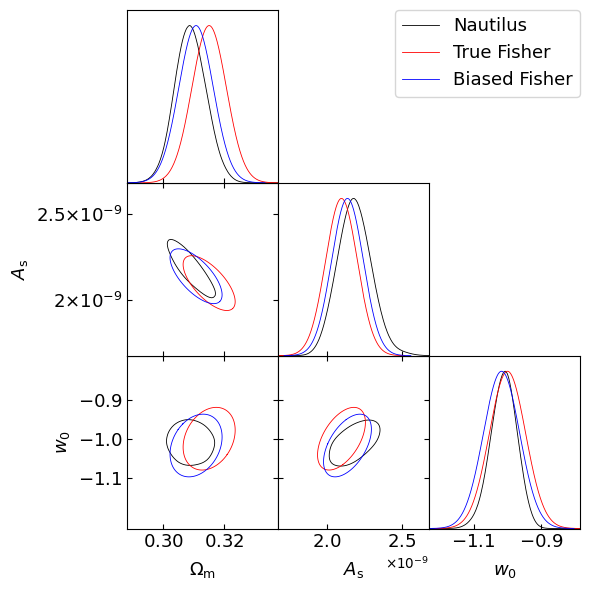

In [11]:
# Triangle plot
g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 16
g.settings.axes_labelsize = 16
g.settings.axes_fontsize = 16
g.settings.num_plot_contours = 1
g.triangle_plot([gd_samples_nautilus, f_true, f_biased],
                legend_labels=['Nautilus', 'True Fisher', 'Biased Fisher'])
#g.export('../output/DESC_vanilla_validation.pdf')

# Find the maximum a posteriori
### Using the Nelder-Mead optimisation method

In [12]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import gaussian_kde

num_dimensions = resized_points.shape[1]

# Perform KDE
kde = gaussian_kde(resized_points.T)

# Define the objective function
def objective(x):
    return -kde(x)

# Initial guess: Mean of the sampled points
initial_guess = resized_points.mean(axis=0)

# Perform Nelder-Mead optimization
result = minimize(objective, initial_guess, method='Nelder-Mead')

# Location of the maximum
max_point_ND = result.x

print(f"Maximum density point: {max_point_ND}")

Maximum density point: [ 3.08988197e-01  2.18261110e-09 -1.01100849e+00]


In [15]:
for ip, p in enumerate(fm_no_baryons.parameters):
    print(f'Bias from NS for {p}: {max_point_ND[ip]-fm_no_baryons.fiducial_parameters[ip]}')

Bias from NS for Omega_m: -0.006011803249441283
Bias from NS for A_s: 8.371110171236298e-11
Bias from NS for w0: -0.011008487380239185
